# Sunrise Social Club: Predictive Modeling

**Objective:** Predict beverage demand to support inventory planning and event preparation.

plan is to predict how much of each drink type we'll sell at a given market/event and equate that to how many gallons to batch. aim for underbatch but prep more as needed.

In [560]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [561]:
df = pd.read_csv("../data/processed/sales_merged.csv")
drink_df = df[df['Item'].isin(['Matcha Latte','Cold Brew','Lemonade'])]

In [562]:
model_df = (
    drink_df.groupby(
        ["Date", "Event_Type", "Location", "Item", "Avg_Temp","Weather_Condition"]
    )["Qty"]
    .sum()
    .reset_index()
)
model_df.head()

,Date,Event_Type,Location,Item,Avg_Temp,Weather_Condition,Qty
0,2026-05-23,Popup,Commercial Kitchen,Matcha Latte,77.0,Partly Cloudy,68.0
1,2026-05-30,Market,Manteo,Cold Brew,79.0,Sunny,51.0
2,2026-05-30,Market,Manteo,Lemonade,79.0,Sunny,21.0
3,2026-05-30,Market,Manteo,Matcha Latte,79.0,Sunny,87.0
4,2026-06-06,Market,Manteo,Cold Brew,86.0,Sunny,46.0


In [563]:
model_df['Date']=pd.to_datetime(model_df['Date'])
model_df['Month']=model_df['Date'].dt.month
model_df['Weekend']= model_df['Date'].dt.dayofweek >=5

In [564]:
X = model_df[[
    "Event_Type",
    "Location",
    "Avg_Temp",
    "Weather_Condition",
    "Month",
    "Weekend",
    "Item"
]]
y=model_df['Qty']

In [565]:
X=pd.get_dummies(X,drop_first=True)

In [566]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [567]:
baseline_pred = np.full_like(y_test, y_train.mean())

In [568]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mae_baseline = mean_absolute_error(y_test, baseline_pred)
mse_baseline = mean_squared_error(y_test, baseline_pred)
rmse_baseline = np.sqrt(mse_baseline)

### Linear Regression

In [569]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [570]:
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = root_mean_squared_error(y_test, pred_lr)

### Random Forest

In [571]:
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
pred_rf=rf.predict(X_test)

In [572]:
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = root_mean_squared_error(y_test, pred_rf)

In [573]:
results = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest"],
    "MAE": [mae_baseline, mae_lr, mae_rf],
    "RMSE": [rmse_baseline, rmse_lr, rmse_rf]
})
results

,Model,MAE,RMSE
0,Baseline,13.516484,17.012749
1,Linear Regression,9.017304,12.811999
2,Random Forest,12.211429,14.698717


Linear regression performed competitively with Random Forest, suggesting that beverage demand is largely driven by linear relationships between weather, event type, and product category, with only minor nonlinear interactions.

In [574]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred_lr
})

results.head(10)

,Actual,Predicted
31,18.0,27.556212
15,51.0,51.284827
26,58.0,70.306503
17,64.0,64.295083
8,37.0,46.448916
9,25.0,22.214203
19,51.0,22.556212


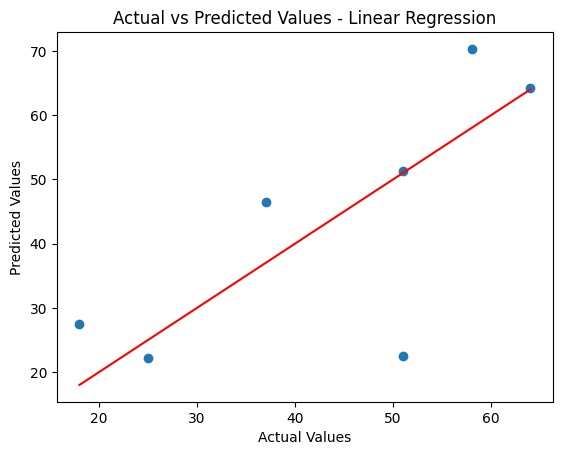

In [575]:
plt.scatter(y_test, pred_lr)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values - Linear Regression")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')   
plt.show()

In [576]:
print("Total rows:", len(model_df))
print("Train size:", len(X_train))
print("Test size:", len(X_test))

Total rows: 33
Train size: 26
Test size: 7


In [577]:
grams_12oz = {
    "Lemonade": 200,
    "Cold Brew": 100,
    "Matcha Latte": 40
}

grams_16oz = {
    "Lemonade": 275,
    "Cold Brew": 180,
    "Matcha Latte": 50
}

In [578]:
def compute_effective_grams():

    mix_16 = 0.8
    mix_12 = 0.2

    effective_grams = {}

    for item in grams_12oz.keys():
        effective_grams[item] = (
            mix_16 * grams_16oz[item] +
            mix_12 * grams_12oz[item]
        )

    return effective_grams

In [579]:
def inventory_calculator(pred_df):

    effective_grams = compute_effective_grams()

    GRAMS_PER_GALLON = 3300

    pred_df["Grams"] = pred_df.apply(
        lambda row: row["Predicted_Qty"] * effective_grams[row["Item"]],
        axis=1
    )

    pred_df["Gallons"] = pred_df["Grams"] / GRAMS_PER_GALLON

    return pred_df

In [580]:
event_input_raw = pd.DataFrame({
    "Event_Type": ["Market"],
    "Location": ["Manteo"],
    "Avg_Temp": [85],
    "Weather_Condition": ["Sunny"],
    "Month": [6],
    "Weekend": [True],
})

In [581]:
def build_event_grid(event_input_raw):

    items = ["Matcha Latte", "Cold Brew", "Lemonade"]

    rows = []

    for item in items:
        row = event_input_raw.copy()
        row["Item"] = item
        rows.append(row)

    return pd.concat(rows, ignore_index=True)

In [582]:
event_grid = build_event_grid(event_input_raw)

event_encoded = pd.get_dummies(event_grid)
event_encoded = event_encoded.reindex(columns=X.columns, fill_value=0)

event_grid["Predicted_Qty"] = lr.predict(event_encoded)

In [583]:
result = inventory_calculator(event_grid)

In [584]:
result

,Event_Type,Location,Avg_Temp,Weather_Condition,Month,Weekend,Item,Predicted_Qty,Grams,Gallons
0,Market,Manteo,85,Sunny,6,True,Matcha Latte,74.466452,3574.389711,1.083148
1,Market,Manteo,85,Sunny,6,True,Cold Brew,61.456197,10078.816268,3.054187
2,Market,Manteo,85,Sunny,6,True,Lemonade,40.017536,10404.559381,3.152897
